# (Homework) Week 7 - DataScience Bootcamp Fall 2025

All solution cells are replaced with `# TODO` placeholders so you can fill them in.

**Name: Bobby Stitt \
**Email: rs8593@nyu.edu

---

## Problem A: Bayesian Dice Game (Posterior Inference)

You are playing a dice game at a carnival. The operator has **three dice**, each with different biases for rolling a six:

| Die | P(6) | P(1–5) |
|-----|------|--------|
| A   | 0.10 | 0.90   |
| B   | 0.30 | 0.70   |
| C   | 0.60 | 0.40   |

Before each round, the operator secretly picks one die at random (each equally likely). He then rolls it **10 times** and tells you how many sixes appeared.

Your job is to infer which die was used using **Bayes’ Theorem**:

$$ P(Die|k) = \frac{P(k|Die)P(Die)}{\sum_{d} P(k|d)P(d)} $$

where $P(k|Die)$ follows a Binomial (n=10, p_i) distribution.

**Tasks:**
1. Simulate the experiment by picking a random die and rolling it 10 times.
2. Compute posterior probabilities for each die given observed sixes.
3. Plot likelihoods and posterior probabilities.
4. Evaluate inference accuracy over 100 rounds.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Dice setup
dice_probs = {'A': 0.1, 'B': 0.3, 'C': 0.6}
dice_names = list(dice_probs.keys())
prior = #TODO
n_rolls = 10

# Compute binomial probability mass function
def binomial_prob(n, k, p):
    #TODO
    pass

def simulate_round():
    #TODO
   pass

def posterior_given_k(k):
    #TODO
    pass

# Example run
true_die, k = simulate_round()
posterior = posterior_given_k(k)

print(f"Observed {k} sixes out of {n_rolls} rolls")
for die, p in zip(dice_names, posterior):
    print(f"P({die} | {k} sixes) = {p:.3f}")
print(f"True die: {true_die}")

# Likelihood plot
ks = np.arange(0, 11)
plt.figure(figsize=(8,5))
for die, p in dice_probs.items():
    plt.plot(ks, [binomial_prob(n_rolls, k, p) for k in ks], label=f"Die {die} (p={p})")
plt.xlabel('Number of sixes observed')
plt.ylabel('P(k | Die)')
plt.legend()
plt.title('Likelihoods of Observing k Sixes for Each Die')
plt.show()

# Accuracy evaluation
num_trials = 100
correct = 0
for _ in range(num_trials):
    true_die, k = simulate_round()
    posterior = posterior_given_k(k)
    predicted_die = dice_names[np.argmax(posterior)]
    correct += (predicted_die == true_die)

print(f"Accuracy over {num_trials} rounds: {correct/num_trials:.2f}")

# Posterior visualizations
posterior_matrix = np.array([posterior_given_k(k) for k in ks])
plt.figure(figsize=(7,5))
plt.imshow(posterior_matrix.T, cmap='viridis', aspect='auto')
plt.xticks(ks)
plt.yticks(range(3), dice_names)
plt.xlabel('Observed number of sixes (k)')
plt.ylabel('Posterior P(Die | k)')
plt.colorbar(label='Probability')
plt.title('Posterior Distribution over Dice for Different Observations')
plt.show()

## Problem B: Linear Regression
Given x=[-2,-1,0,1,2] and y=[7,4,3,4,7]. Fit a linear model using the normal equation.

In [ ]:
x = np.array([-2, -1, 0, 1, 2])
y = np.array([7, 4, 3, 4, 7])

X = np.c_[np.ones(len(x)), x]
theta = np.linalg.inv(X.T @ X) @ X.T @ y
y_pred = X @ theta
mse_linear = np.mean((y - y_pred) ** 2)
print('Linear theta:', theta, 'MSE:', mse_linear)

## Problem C: Gradient Descent
Minimize f(w)=5(w−11)^4. Perform steps with α=1/400 and α=1/4000000. (Print the first 5 steps and visualize)

GRADIENT DESCENT: Minimizing f(w) = 5(w - 11)^4

LEARNING RATE α = 1/400 = 0.0025

First 5 steps:
Step | w          | f(w)        | gradient
------------------------------------------------------------
   0 |  13.000000 |   80.000000 |   160.000000
   1 |  12.600000 |   32.768000 |    81.920000
   2 |  12.395200 |   18.945928 |    54.317453
   3 |  12.259406 |   12.578636 |    39.951000
   4 |  12.159529 |    9.038498 |    31.179898
   5 |  12.081579 |    6.842317 |    25.304915

Final result (step 200):
  w = 11.22034109
  f(w) = 0.01178561
  Distance from minimum (w=11): 0.22034109

LEARNING RATE α = 1/4000000 = 0.00000025

First 5 steps:
Step | w          | f(w)        | gradient
------------------------------------------------------------
   0 |  13.000000 |   80.000000 |   160.000000
   1 |  12.999960 |   79.993600 |   159.990400
   2 |  12.999920 |   79.987201 |   159.980801
   3 |  12.999880 |   79.980803 |   159.971203
   4 |  12.999840 |   79.974405 |   159.961607
   5 |  12.9

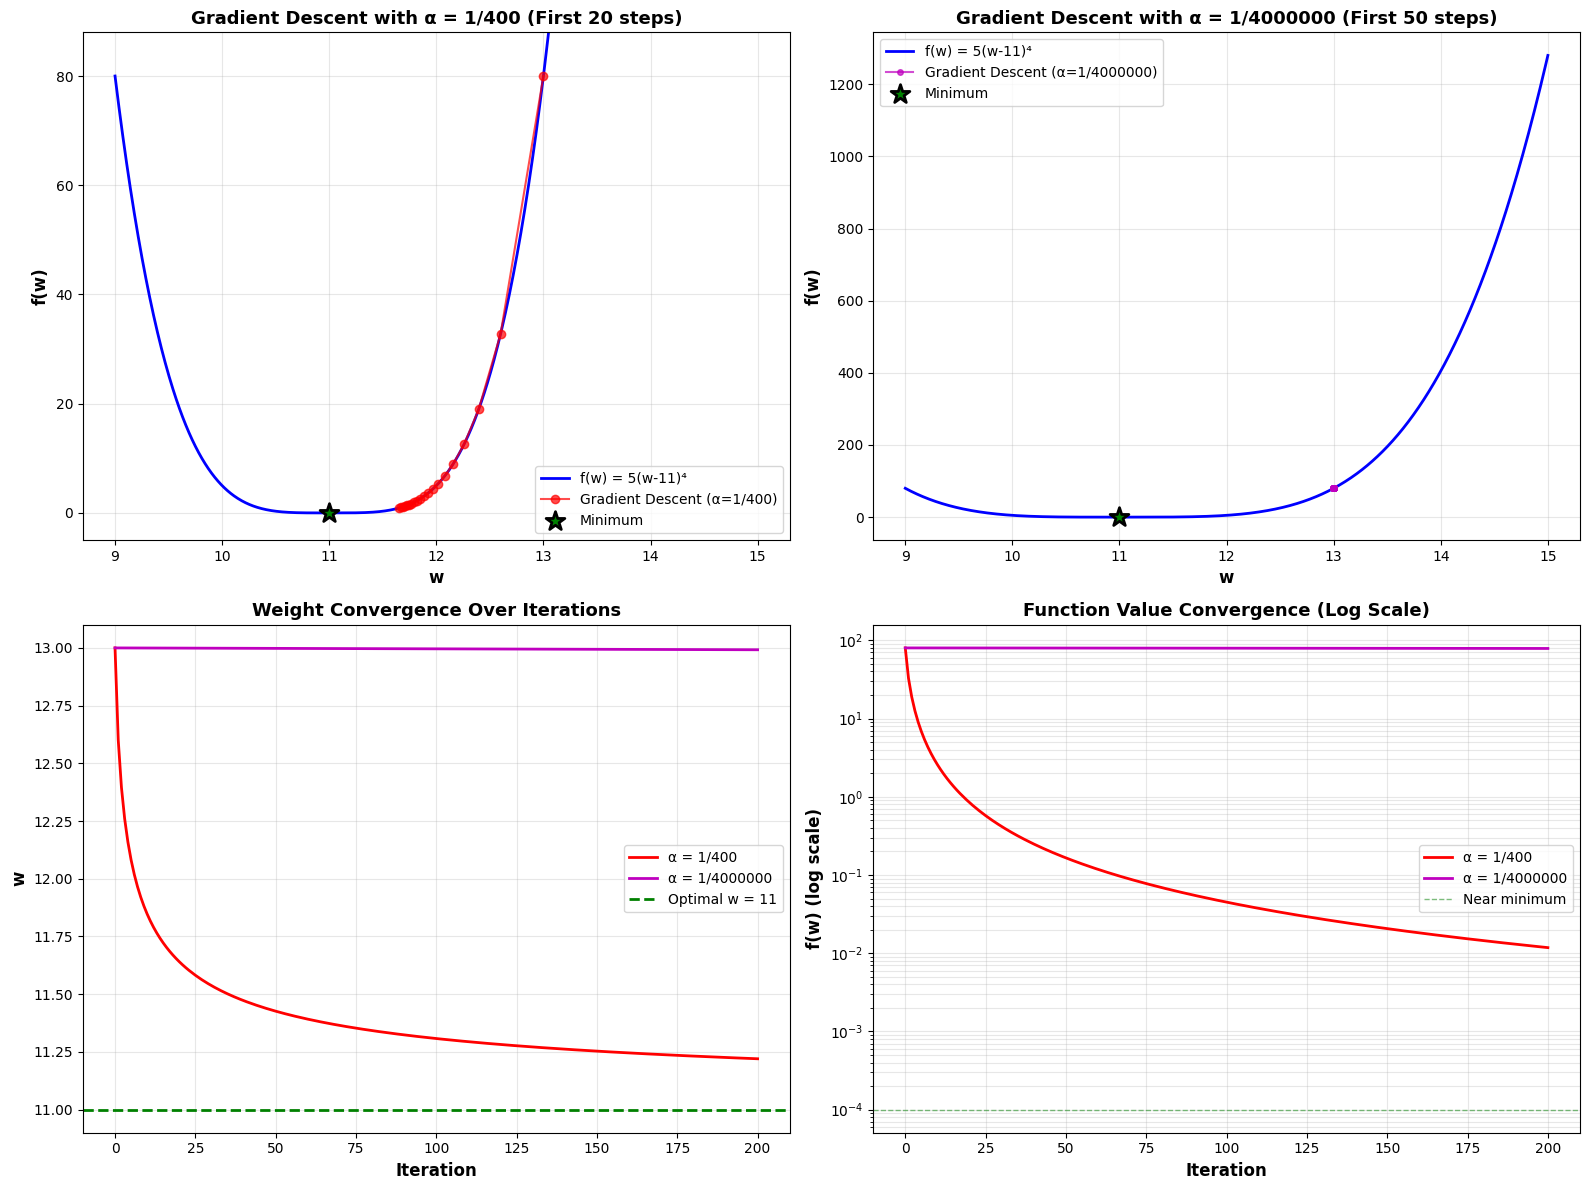

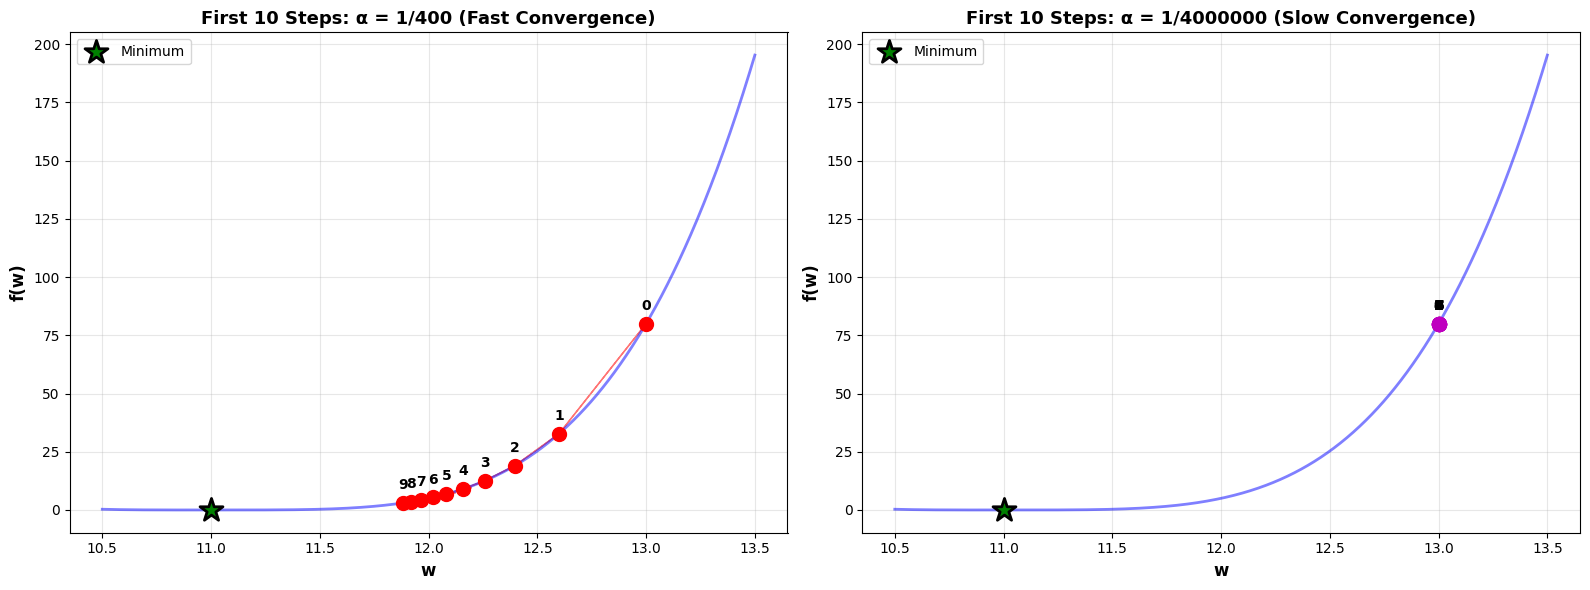

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function and its gradient
def f(w):
    """Objective function: f(w) = 5(w - 11)^4"""
    return 5 * (w - 11)**4

def grad_f(w):
    """Gradient of f(w): f'(w) = 20(w - 11)^3"""
    return 20 * (w - 11)**3

# Gradient Descent Function
def grad_descent_vals(w0, alpha, steps):
    """
    Perform gradient descent

    Args:
        w0: Initial weight
        alpha: Learning rate
        steps: Number of iterations

    Returns:
        history: List of (w, f(w)) tuples at each step
    """
    history = []
    w = w0

    for i in range(steps + 1):  # +1 to include initial value
        # Record current state
        history.append((w, f(w)))

        # Update using gradient descent: w_new = w_old - alpha * gradient
        if i < steps:  # Don't update after last recording
            gradient = grad_f(w)
            w = w - alpha * gradient

    return history

# Run for two learning rates
print("="*80)
print("GRADIENT DESCENT: Minimizing f(w) = 5(w - 11)^4")
print("="*80)

# Learning rate 1: α = 1/400
print("\n" + "="*80)
print("LEARNING RATE α = 1/400 = 0.0025")
print("="*80)
hist_140 = grad_descent_vals(13, 1/400, 200)

print("\nFirst 5 steps:")
print("Step | w          | f(w)        | gradient")
print("-" * 60)
for i in range(min(6, len(hist_140))):
    w_val, f_val = hist_140[i]
    grad_val = grad_f(w_val)
    print(f"{i:4d} | {w_val:10.6f} | {f_val:11.6f} | {grad_val:12.6f}")

print(f"\nFinal result (step 200):")
print(f"  w = {hist_140[-1][0]:.8f}")
print(f"  f(w) = {hist_140[-1][1]:.8f}")
print(f"  Distance from minimum (w=11): {abs(hist_140[-1][0] - 11):.8f}")

# Learning rate 2: α = 1/4000000
print("\n" + "="*80)
print("LEARNING RATE α = 1/4000000 = 0.00000025")
print("="*80)
hist_180 = grad_descent_vals(13, 1/4000000, 200)

print("\nFirst 5 steps:")
print("Step | w          | f(w)        | gradient")
print("-" * 60)
for i in range(min(6, len(hist_180))):
    w_val, f_val = hist_180[i]
    grad_val = grad_f(w_val)
    print(f"{i:4d} | {w_val:10.6f} | {f_val:11.6f} | {grad_val:12.6f}")

print(f"\nFinal result (step 200):")
print(f"  w = {hist_180[-1][0]:.8f}")
print(f"  f(w) = {hist_180[-1][1]:.8f}")
print(f"  Distance from minimum (w=11): {abs(hist_180[-1][0] - 11):.8f}")

# Comparison
print("\n" + "="*80)
print("COMPARISON")
print("="*80)
print(f"α = 1/400:     Final w = {hist_140[-1][0]:.8f}, f(w) = {hist_140[-1][1]:.8f}")
print(f"α = 1/4000000: Final w = {hist_180[-1][0]:.8f}, f(w) = {hist_180[-1][1]:.8f}")
print(f"\nOptimal w = 11 (minimum of f(w) = 0)")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

# Plot 1: Function and both trajectories
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1a: α = 1/400 trajectory
ax = axes[0, 0]
w_range = np.linspace(9, 15, 1000)
f_range = f(w_range)

ax.plot(w_range, f_range, 'b-', linewidth=2, label='f(w) = 5(w-11)⁴')
w_vals_140 = [h[0] for h in hist_140[:20]]  # First 20 steps
f_vals_140 = [h[1] for h in hist_140[:20]]
ax.plot(w_vals_140, f_vals_140, 'ro-', markersize=6, linewidth=1.5,
        label=f'Gradient Descent (α=1/400)', alpha=0.7)
ax.scatter([11], [0], color='green', s=200, marker='*',
           edgecolors='black', linewidths=2, label='Minimum', zorder=5)
ax.set_xlabel('w', fontsize=12, fontweight='bold')
ax.set_ylabel('f(w)', fontsize=12, fontweight='bold')
ax.set_title('Gradient Descent with α = 1/400 (First 20 steps)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, max(f_vals_140[:20]) * 1.1)

# Plot 1b: α = 1/4000000 trajectory
ax = axes[0, 1]
ax.plot(w_range, f_range, 'b-', linewidth=2, label='f(w) = 5(w-11)⁴')
w_vals_180 = [h[0] for h in hist_180[:50]]  # First 50 steps
f_vals_180 = [h[1] for h in hist_180[:50]]
ax.plot(w_vals_180, f_vals_180, 'mo-', markersize=4, linewidth=1.5,
        label=f'Gradient Descent (α=1/4000000)', alpha=0.7)
ax.scatter([11], [0], color='green', s=200, marker='*',
           edgecolors='black', linewidths=2, label='Minimum', zorder=5)
ax.set_xlabel('w', fontsize=12, fontweight='bold')
ax.set_ylabel('f(w)', fontsize=12, fontweight='bold')
ax.set_title('Gradient Descent with α = 1/4000000 (First 50 steps)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2a: Convergence over iterations (w values)
ax = axes[1, 0]
steps_140 = range(len(hist_140))
steps_180 = range(len(hist_180))
w_vals_140_all = [h[0] for h in hist_140]
w_vals_180_all = [h[0] for h in hist_180]

ax.plot(steps_140, w_vals_140_all, 'r-', linewidth=2, label='α = 1/400')
ax.plot(steps_180, w_vals_180_all, 'm-', linewidth=2, label='α = 1/4000000')
ax.axhline(y=11, color='green', linestyle='--', linewidth=2, label='Optimal w = 11')
ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('w', fontsize=12, fontweight='bold')
ax.set_title('Weight Convergence Over Iterations', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2b: Convergence over iterations (f(w) values) - log scale
ax = axes[1, 1]
f_vals_140_all = [h[1] for h in hist_140]
f_vals_180_all = [h[1] for h in hist_180]

ax.semilogy(steps_140, f_vals_140_all, 'r-', linewidth=2, label='α = 1/400')
ax.semilogy(steps_180, f_vals_180_all, 'm-', linewidth=2, label='α = 1/4000000')
ax.axhline(y=0.0001, color='green', linestyle='--', linewidth=1, alpha=0.5,
           label='Near minimum')
ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax.set_ylabel('f(w) (log scale)', fontsize=12, fontweight='bold')
ax.set_title('Function Value Convergence (Log Scale)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('gradient_descent_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional detailed plot for first few steps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Zoomed view for α = 1/400
ax = axes[0]
w_range_zoom = np.linspace(10.5, 13.5, 1000)
f_range_zoom = f(w_range_zoom)
ax.plot(w_range_zoom, f_range_zoom, 'b-', linewidth=2, alpha=0.5)

for i in range(min(10, len(hist_140))):
    w_val, f_val = hist_140[i]
    ax.plot(w_val, f_val, 'ro', markersize=10, zorder=3)
    ax.annotate(f'{i}', (w_val, f_val), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=10, fontweight='bold')
    if i > 0:
        w_prev, f_prev = hist_140[i-1]
        ax.arrow(w_prev, f_prev, w_val - w_prev, f_val - f_prev,
                head_width=0.05, head_length=0.5, fc='red', ec='red',
                alpha=0.5, length_includes_head=True)

ax.scatter([11], [0], color='green', s=300, marker='*',
           edgecolors='black', linewidths=2, label='Minimum', zorder=5)
ax.set_xlabel('w', fontsize=12, fontweight='bold')
ax.set_ylabel('f(w)', fontsize=12, fontweight='bold')
ax.set_title('First 10 Steps: α = 1/400 (Fast Convergence)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Zoomed view for α = 1/4000000
ax = axes[1]
ax.plot(w_range_zoom, f_range_zoom, 'b-', linewidth=2, alpha=0.5)

for i in range(min(10, len(hist_180))):
    w_val, f_val = hist_180[i]
    ax.plot(w_val, f_val, 'mo', markersize=10, zorder=3)
    ax.annotate(f'{i}', (w_val, f_val), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=10, fontweight='bold')
    if i > 0:
        w_prev, f_prev = hist_180[i-1]
        ax.arrow(w_prev, f_prev, w_val - w_prev, f_val - f_prev,
                head_width=0.05, head_length=0.5, fc='magenta', ec='magenta',
                alpha=0.5, length_includes_head=True)

ax.scatter([11], [0], color='green', s=300, marker='*',
           edgecolors='black', linewidths=2, label='Minimum', zorder=5)
ax.set_xlabel('w', fontsize=12, fontweight='bold')
ax.set_ylabel('f(w)', fontsize=12, fontweight='bold')
ax.set_title('First 10 Steps: α = 1/4000000 (Slow Convergence)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('gradient_descent_first_steps.png', dpi=150, bbox_inches='tight')
plt.show()

ALL THE BEST!